# MLforBoneImaging

Paper: *Demystifying Machine Learning Approaches in Digital Bone Imaging using MicroCT and HRpQCT* (Bone Reports, 2026)  
Authors: Michael A. David, Kyle G. Williams, Evangelia P. Constantine, Julia Matthias, Virginia L. Ferguson, Douglas J. Adams

Choose your path:
- **Read-only**: scroll and read. No setup needed.
- **Rerun figures**: run the setup cell once, then jump to the figure section(s) below and run only those cells.
- **Rerun PubMed merge**: run the setup cell, then run the “Merge PubMed searches” section to regenerate `data/df_pubmed_searches_deduplicated.csv` (the table you would import into SciNetX). `data/PubMedSearchesWords.csv` is a lookup table listing the PubMed search terms used.

Open in Colab:
https://colab.research.google.com/github/madavid128/2026-BoneRep-MLforBoneImaging/blob/main/notebooks/MLforBoneImaging.ipynb

Cite the paper and repository (see `CITATION.cff`).


In [ ]:
# Colab setup (run this cell first only if you want to run code in Colab)
# Reading-only: you can skip this cell.
# Default: clone the repo from GitHub into the temporary Colab runtime.
# Optional: set USE_DRIVE = True to mount Google Drive and keep the repo/outputs between Colab sessions.
# Local: skip this cell if you already installed dependencies and started Jupyter from the repo root.

import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/madavid128/2026-BoneRep-MLforBoneImaging'  # only needed in Colab
USE_DRIVE = False  # Colab optional: set True to use Google Drive (keeps files between sessions)

if IN_COLAB:
    repo_dirname = REPO_URL.rstrip('/').split('/')[-1]

    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        repo_path = Path('/content/drive/MyDrive') / repo_dirname
    else:
        repo_path = Path('/content') / repo_dirname

    if not repo_path.exists():
        if not REPO_URL.startswith('http'):
            raise ValueError('Set REPO_URL to the GitHub repository URL first.')
        repo_path.parent.mkdir(parents=True, exist_ok=True)
        subprocess.check_call(['git', 'clone', REPO_URL, str(repo_path)])

    os.chdir(repo_path)

    subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', 'uv'])

    candidates = (
        ['requirements.lock', 'requirements.txt']
        if Path('requirements.lock').exists()
        else ['requirements.txt']
    )

    def install_requirements(cmd_prefix):
        for req_file in candidates:
            try:
                print(f'Installing dependencies from {req_file}...')
                subprocess.check_call(cmd_prefix + ['-r', req_file])
                return req_file
            except Exception:
                print(f'Failed installing from {req_file}.')
        return None

    used = install_requirements(['uv', 'pip', 'install'])
    if used is None:
        used = install_requirements([sys.executable, '-m', 'pip', 'install'])

    if used is None:
        raise RuntimeError('Dependency install failed (requirements.lock/requirements.txt).')

REPO_ROOT = Path('.').resolve()
print('REPO_ROOT =', REPO_ROOT)


In [ ]:
# Environment / versions (optional)
# Helps long-term reproducibility when rerunning in Colab or locally.

import platform
import sys

try:
    from importlib import metadata as importlib_metadata
except Exception:  # pragma: no cover
    import importlib_metadata  # type: ignore

def dist_version(name: str):
    try:
        return importlib_metadata.version(name)
    except Exception:
        return None

def module_version(module_name: str):
    try:
        mod = __import__(module_name)
        return getattr(mod, '__version__', None)
    except Exception:
        return None

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())

packages = [
    ('uv', 'uv'),
    ('numpy', 'numpy'),
    ('pandas', 'pandas'),
    ('matplotlib', 'matplotlib'),
    ('scikit-learn', 'sklearn'),
    ('xgboost', 'xgboost'),
    ('umap-learn', 'umap'),
    ('opencv-python', 'cv2'),
    ('shap', 'shap'),
]

for dist, module in packages:
    v = dist_version(dist) or module_version(module)
    if v is not None:
        print(f'{dist}: {v}')
    else:
        print(f'{dist}: (not installed)')


In [ ]:
# Paths used in the PubMed merge section
from pathlib import Path

dir_path = str(Path('.').resolve())
dir_pubmed_searches_path = str(Path(dir_path) / 'pubmed_searches')
print('dir_pubmed_searches_path =', dir_pubmed_searches_path)


## How to run this notebook (quick)

- **Read-only**: scroll and read. No setup needed.
- **Rerun figures**: run the setup cell once (Colab or local), then jump to the figure section(s) and run only those cells.
- **Rerun PubMed merge**: run the setup cell, then run the merge section to regenerate `data/df_pubmed_searches_deduplicated.csv` (the table you would import into SciNetX).

Colab notes:
- The setup cell installs dependencies and prepares the repo.
- Optional: set `USE_DRIVE = True` in the setup cell to keep files between Colab sessions.

Local notes:
- Start Jupyter from the repo root and run cells top-to-bottom.

### Inputs

- PubMed export CSVs in `pubmed_searches/` (used to build the merged literature table).

### Outputs

- `data/df_pubmed_searches_deduplicated.csv`: merged PubMed exports (output of the merge section; can be imported into SciNetX).
- `data/References.csv`: curated “final” reference table used for downstream analysis/figures.
- `data/PubMedSearchesWords.csv`: lookup table listing the PubMed search terms used.
- `networks/`: interactive network pages (open `networks/index.html`).

If you get a file-not-found error, see `docs/TROUBLESHOOTING.md`.


## Contents

- Merge PubMed searches (literature table)
- Prediction (Figure 7C)
- Classification (Figure 7D)
- Dimensionality reduction & clustering (Figure 8)
- Grad-CAM illustration (Figure 9B)
- SHAP illustration (Figure 9C)
- Radar plots (Figure 9D)

For review, start with the curated “final” table: `data/References.csv`.

Tip: the merged literature table is saved to `data/df_pubmed_searches_deduplicated.csv`.


## Merge PubMed searches (literature table)


In [1]:
import pandas as pd
from pathlib import Path

def load_and_merge_csvs(
    dir_path,
    id_col="PMID",
    skip_files=None,          # list of exact filenames to skip (e.g., ["bad.csv"])
    skip_contains=None,       # list of substrings; any filename containing one is skipped
    dataset_col="dataset",
    read_csv_kwargs=None      # e.g., {"sep":";", "encoding":"utf-8"}
):
    """Load all `*.csv` files from a folder and concatenate them into one table.

    Each input CSV must contain an identifier column (default: `PMID`).
    The function adds a `dataset` column based on the source filename and
    creates `duplicate_count` / `duplicate` fields to flag repeated PMIDs.

    This is the main helper used to merge the PubMed search exports in `pubmed_searches/`.
    """

    dir_path = Path(dir_path)
    if not dir_path.is_dir():
        raise ValueError(f"Not a directory: {dir_path}")

    skip_files = set(skip_files or [])
    skip_contains = skip_contains or []
    read_csv_kwargs = read_csv_kwargs or {}

    csv_paths = sorted(p for p in dir_path.glob("*.csv")
                       if p.name not in skip_files
                       and not any(sub in p.name for sub in skip_contains))

    if not csv_paths:
        raise ValueError("No CSV files found after applying skip filters.")

    dfs = []
    for p in csv_paths:
        try:
            df = pd.read_csv(p, **read_csv_kwargs)
        except Exception as e:
            print(f"⚠️ Skipping {p.name}: failed to read ({e})")
            continue

        if id_col not in df.columns:
            print(f"⚠️ Skipping {p.name}: missing required id_col '{id_col}'")
            continue

        # add dataset name from filename (without extension)
        df = df.copy()
        df[dataset_col] = p.stem
        dfs.append(df)

    if not dfs:
        raise ValueError("No valid CSVs loaded (all failed or missing id_col).")

    combined_df = pd.concat(dfs, ignore_index=True)

    # combine dataset names across duplicate IDs (unique + stable order)
    combined_df[dataset_col] = (
        combined_df
        .groupby(id_col)[dataset_col]
        .transform(lambda x: ", ".join(pd.unique(x)))
    )

    # count duplicates and add flag
    combined_df["duplicate_count"] = combined_df.groupby(id_col)[id_col].transform("count")
    combined_df["duplicate"] = combined_df["duplicate_count"].gt(1).map({True: "duplicate", False: "not"})

    # drop duplicate IDs, keep first occurrence
    result_df = combined_df.drop_duplicates(subset=id_col, keep="first").reset_index(drop=True)
    return result_df

## Run merge


This step reads all `*.csv` files in `pubmed_searches/` and merges them into a single table called `result_df`.

- A `dataset` column is added based on the source filename (e.g., `search_01`).
- `duplicate_count` and `duplicate` indicate whether a PMID appeared in multiple searches.

After running the next cell, you can preview the table (`result_df.head()`), and it will be saved to `data/df_pubmed_searches_deduplicated.csv`.


In [ ]:
# Uses dir_pubmed_searches_path set above
result_df = load_and_merge_csvs(
    dir_pubmed_searches_path,
    id_col='PMID',
    skip_files=[],
    skip_contains=['draft', 'temp'],
    read_csv_kwargs={'encoding': 'utf-8'}
)


In [3]:
result_df.head(5)

,PMID,Title,Authors,Citation,First Author,Journal/Book,Publication Year,Create Date,PMCID,NIHMS ID,DOI,dataset,duplicate_count,duplicate
0,36328744,Single-cell RNA sequencing analysis reveals th...,"Zhong J, Mao X, Li H, Shen G, Cao X, He N, Wan...",J Adv Res. 2022 Nov;41:145-158. doi: 10.1016/j...,Zhong J,J Adv Res,2022,2022/11/03,PMC9637485,NaN,10.1016/j.jare.2022.01.006,"search_01, search_02",2,duplicate
1,26497626,Resveratrol prevents alveolar bone loss in an ...,"Bhattarai G, Poudel SB, Kook SH, Lee JC.",Acta Biomater. 2016 Jan;29:398-408. doi: 10.10...,Bhattarai G,Acta Biomater,2016,2015/10/27,NaN,NaN,10.1016/j.actbio.2015.10.031,"search_01, search_02",2,duplicate
2,32783967,Deep learning for 3D imaging and image analysi...,"Reznikov N, Buss DJ, Provencher B, McKee MD, P...",J Struct Biol. 2020 Oct 1;212(1):107598. doi: ...,Reznikov N,J Struct Biol,2020,2020/08/14,NaN,NaN,10.1016/j.jsb.2020.107598,"search_01, search_013, search_014, search_015,...",8,duplicate
3,38385868,Semi-Automated MicroCT Analysis of Bone Anatom...,"Spoutil F, Dlugosova S, Varga I, Aranaz-Novali...",Curr Protoc. 2024 Feb;4(2):e980. doi: 10.1002/...,Spoutil F,Curr Protoc,2024,2024/02/22,NaN,NaN,10.1002/cpz1.980,"search_01, search_013, search_014, search_015,...",6,duplicate
4,37387366,PRRX1(+)MSCs Enhance Mandibular Regeneration d...,"Jiang WD, Zhu PQ, Zhang T, Liao FC, Jiang PP, ...",J Dent Res. 2023 Aug;102(9):1058-1068. doi: 10...,Jiang WD,J Dent Res,2023,2023/06/30,NaN,NaN,10.1177/00220345231176522,"search_01, search_02, search_03",3,duplicate


### Quick summary (optional)

A short summary of the merged literature table.


In [ ]:
print('Rows (unique PMIDs):', len(result_df))
print('PMIDs appearing in multiple searches:', (result_df['duplicate'] == 'duplicate').sum())
print('Unique datasets tags:', result_df['dataset'].nunique())


In [ ]:
## Save DataFrame ##
import os
from pathlib import Path

dir_path = str(Path('.').resolve())
result_dir = str(Path(dir_path) / 'data')
os.makedirs(result_dir, exist_ok=True)

result_df.to_csv(f'{result_dir}/df_pubmed_searches_deduplicated.csv', index=False, encoding='utf-8-sig')


In [ ]:
# Reproducibility: file checksums (optional)
# Use these SHA256 values to compare outputs across runs/environments.

import hashlib
from pathlib import Path

def sha256_file(path: Path) -> str | None:
    if not path.exists() or not path.is_file():
        return None
    h = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

files = [
    Path('data') / 'References.csv',
    Path('data') / 'df_pubmed_searches_deduplicated.csv',
    Path('data') / 'PubMedSearchesWords.csv',
]

for p in files:
    digest = sha256_file(p)
    if digest is None:
        print(f'{p}: (missing)')
    else:
        print(f'{p}: {digest}')


## Download outputs (Colab)

Optional: in Colab, download the merged table and the interactive networks as a ZIP.



In [ ]:
import sys
import shutil
from pathlib import Path

merged_csv = Path('data') / 'df_pubmed_searches_deduplicated.csv'
networks_dir = Path('networks')

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import files
    if merged_csv.exists():
        files.download(str(merged_csv))
    if networks_dir.exists():
        shutil.make_archive('networks', 'zip', str(networks_dir))
        files.download('networks.zip')


# Prediction (Figure 7C)

This section contains the code used to generate Figure 7C.

- It runs in the notebook and typically produces plots inline.
- Note: SHAP plots are optional and are not required to reproduce Figure 7C.
- If you are only interested in the merged PubMed table, you can skip to later sections.


In [ ]:
!pip install shap

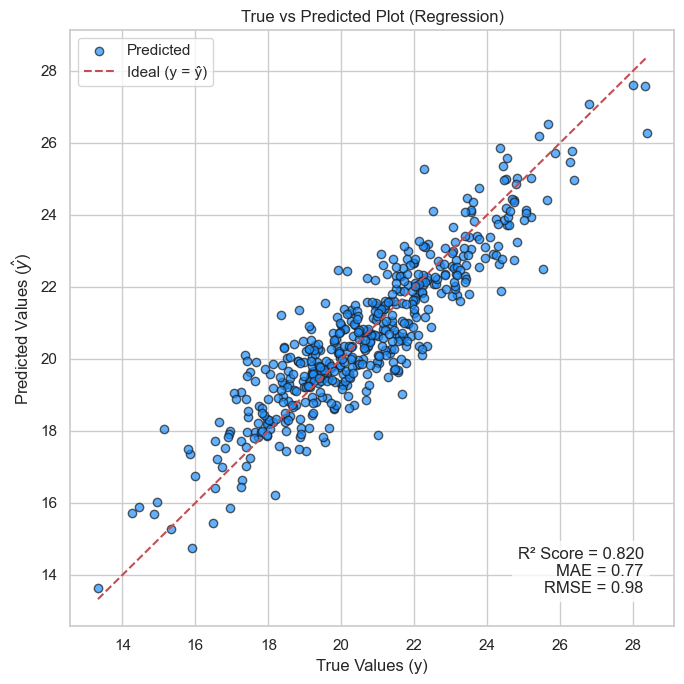

/var/folders/qd/7nrqppz13dl6c5_qwj1lk_180000gn/T/ipykernel_88345/3568113225.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_scaled, feature_names=["Feature 1 (+)", "Feature 2 (−)", "Feature 3 (0)"])


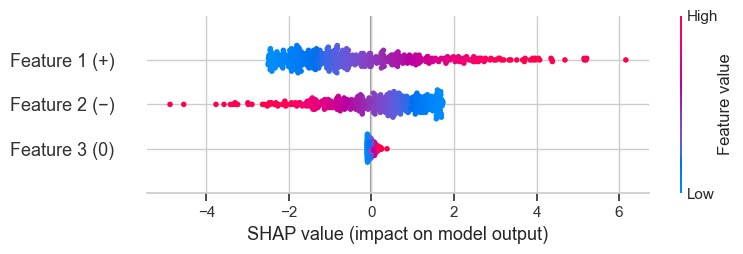

In [3]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

# === Simulate data: all feature values >= 0 ===
np.random.seed(42)
n_samples = 500
X = np.abs(np.random.normal(size=(n_samples, 3))) +15  # All values ≥ 0

# Feature directions:
# Feature 1: Positive impact
# Feature 2: Negative impact
# Feature 3: No impact
y_true = 3 * X[:, 0] - 2 * X[:, 1] + 5  # Add offset to make y ≥ 0
y_true += np.random.normal(0, 1, size=n_samples)  # Add small noise

# === Standardize features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Train model ===
model = LinearRegression()
model.fit(X_scaled, y_true)
y_pred = model.predict(X_scaled)

# === Metrics ===
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# === Plot: True vs Predicted ===
plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, color='dodgerblue', alpha=0.7, edgecolor='k', label='Predicted')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal (y = ŷ)')

plt.xlabel('True Values (y)')
plt.ylabel('Predicted Values ($\hat{y}$)')
plt.title('True vs Predicted Plot (Regression)')
plt.grid(True)

metrics_text = f"R² Score = {r2:.3f}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}"
plt.text(0.95, 0.05, metrics_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend()
plt.tight_layout()
plt.show()

# === SHAP (optional; not required for Figure 7C) ===
if HAS_SHAP:
    explainer = shap.Explainer(model.predict, X_scaled)
    shap_values = explainer(X_scaled)

    shap.summary_plot(shap_values, X_scaled, feature_names=["Feature 1 (+)", "Feature 2 (−)", "Feature 3 (0)"])
else:
    print('SHAP not installed; skipping SHAP plots (Figure 7C still runs).')


# Classification (Figure 7D)

This section contains the code used to generate Figure 7D.

- It produces plots inline in the notebook.


/Users/mdavid/anaconda3/envs/ML_models_utility/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/mdavid/anaconda3/envs/ML_models_utility/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


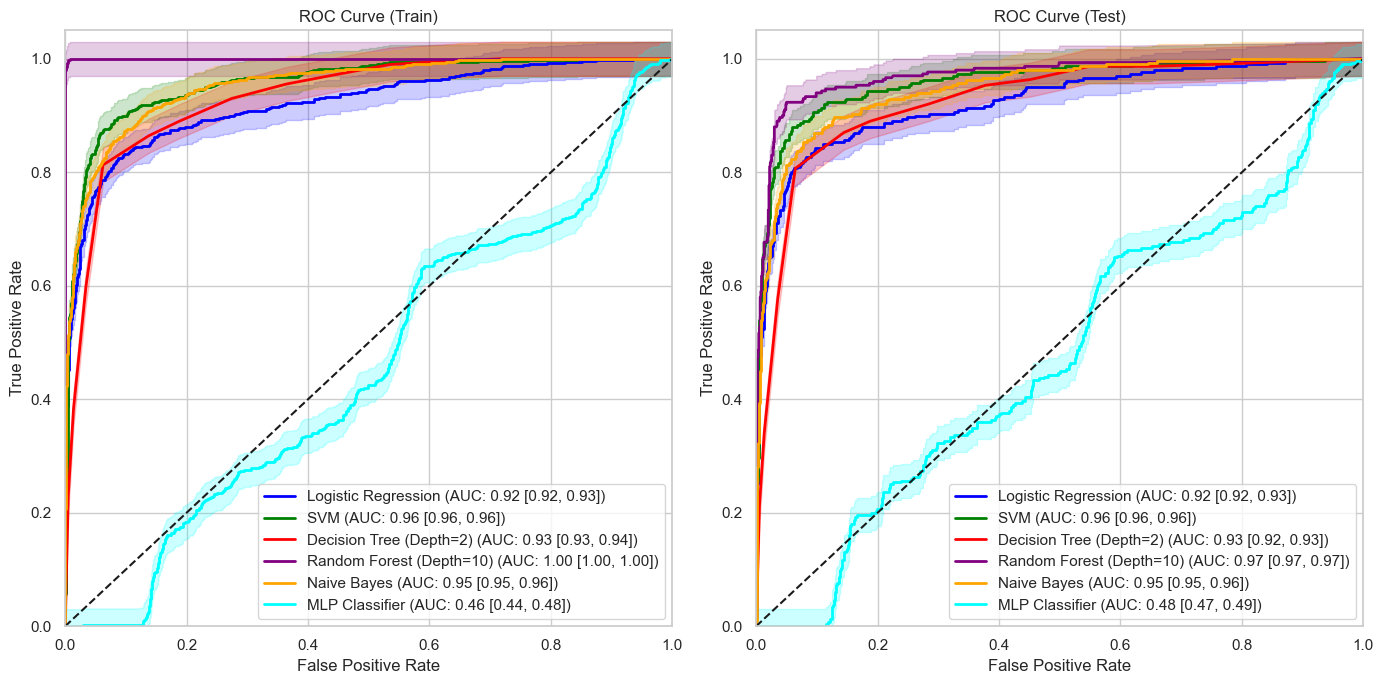

,Test AUC,F1 Score,Precision,Recall,Balanced Accuracy
Logistic Regression,0.924233,0.807232,0.814724,0.804870,0.804870
SVM,0.959348,0.845251,0.851849,0.844116,0.844116
Decision Tree (Depth=2),0.926009,0.799394,0.819629,0.800732,0.800732
Random Forest (Depth=10),0.970326,0.882019,0.893316,0.881591,0.881591
Naive Bayes,0.947978,0.828567,0.839203,0.827595,0.827595
MLP Classifier,0.477333,0.193241,0.145717,0.302830,0.302830


In [1]:

# === Imports ===
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, auc, f1_score, precision_score, recall_score, balanced_accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.utils import resample

# === Function Definitions ===

def plot_decision_boundary(model, X, y, ax, title):
    """Plot decision boundary with markers for each class."""
    DecisionBoundaryDisplay.from_estimator(model, X, cmap='coolwarm', ax=ax, alpha=0.8)
    markers = ['o', 's', '^', 'P']
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, style=y, palette='coolwarm',
                    markers=markers, edgecolor='k', ax=ax, s=100)
    ax.set_title(title)

def plot_roc_with_ci(fpr, tpr, auc_score, auc_ci, model_name, ax, color, dataset_type):
    """Plot ROC curve with AUC and confidence interval."""
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC: {auc_score:.2f} [{auc_ci[0]:.2f}, {auc_ci[1]:.2f}])')
    ax.fill_between(fpr, tpr - 0.03, tpr + 0.03, color=color, alpha=0.2)
    ax.set_title(f'ROC Curve ({dataset_type})')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')

def bootstrap_auc(y_true, y_proba, n_bootstrap=5, random_state=42):
    """Compute bootstrap-based confidence intervals for AUC."""
    np.random.seed(random_state)
    bootstrapped_aucs = []
    for i in range(n_bootstrap):
        indices = resample(np.arange(len(y_true)), replace=True, random_state=i)
        if len(np.unique(y_true[indices])) < 2:
            continue
        auc_value = roc_auc_score(y_true[indices], y_proba[indices])
        bootstrapped_aucs.append(auc_value)
    sorted_aucs = np.sort(bootstrapped_aucs)
    lower_ci = np.percentile(sorted_aucs, 2.5)
    upper_ci = np.percentile(sorted_aucs, 97.5)
    return lower_ci, upper_ci

# === Data Generation ===
X, y = make_classification(n_samples=1000, n_features=2, n_classes=4,
                           n_clusters_per_class=1, random_state=42, n_informative=2,
                           n_redundant=0, n_repeated=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_train_bin = label_binarize(y_train, classes=[0, 1, 2, 3])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

# === Model Definitions ===
models = {
    'Logistic Regression': LogisticRegression(multi_class='ovr'),
    'SVM': SVC(kernel='linear', probability=True),
    'Decision Tree (Depth=2)': DecisionTreeClassifier(max_depth=2),
    'Random Forest (Depth=10)': RandomForestClassifier(max_depth=10, n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'MLP Classifier': MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000,
                                     learning_rate_init=0.001, early_stopping=True, random_state=42)
}

# === Plot Settings ===
colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']
sns.set(style="whitegrid")
fig, (ax_train, ax_test) = plt.subplots(1, 2, figsize=(14, 7))

# === Evaluation and Plotting ===
metrics = {}
for (name, model), color in zip(models.items(), colors):
    model.fit(X_train, y_train)

    # Training ROC
    fpr_train, tpr_train, _ = roc_curve(y_train_bin.ravel(), model.predict_proba(X_train).ravel())
    roc_auc_train = auc(fpr_train, tpr_train)
    auc_ci_train = bootstrap_auc(y_train_bin.ravel(), model.predict_proba(X_train).ravel())
    plot_roc_with_ci(fpr_train, tpr_train, roc_auc_train, auc_ci_train, name, ax_train, color=color, dataset_type='Train')

    # Test ROC
    fpr_test, tpr_test, _ = roc_curve(y_test_bin.ravel(), model.predict_proba(X_test).ravel())
    roc_auc_test = auc(fpr_test, tpr_test)
    auc_ci_test = bootstrap_auc(y_test_bin.ravel(), model.predict_proba(X_test).ravel())
    plot_roc_with_ci(fpr_test, tpr_test, roc_auc_test, auc_ci_test, name, ax_test, color=color, dataset_type='Test')

    # Store summary metrics
    y_test_pred = model.predict(X_test)
    metrics[name] = {
        'Test AUC': roc_auc_test,
        'F1 Score': f1_score(y_test, y_test_pred, average='macro'),
        'Precision': precision_score(y_test, y_test_pred, average='macro'),
        'Recall': recall_score(y_test, y_test_pred, average='macro'),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_test_pred)
    }

# === Final Plot Adjustments ===
for ax in [ax_train, ax_test]:
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

ax_train.set_title('ROC Curve (Train)')
ax_test.set_title('ROC Curve (Test)')
plt.tight_layout()
plt.show()

# === Display Metrics ===
metrics_df = pd.DataFrame(metrics).T
display(metrics_df)

# Dimensionality Reduction (PCA, UMAP, tSNE) and Cluster Analysis

This section generates dimensionality reduction and clustering figures.

- It produces plots inline.
- The “Calculate Clustering Metrics” subsection computes metrics like silhouette score.


## Generate Data (Figure 8B)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


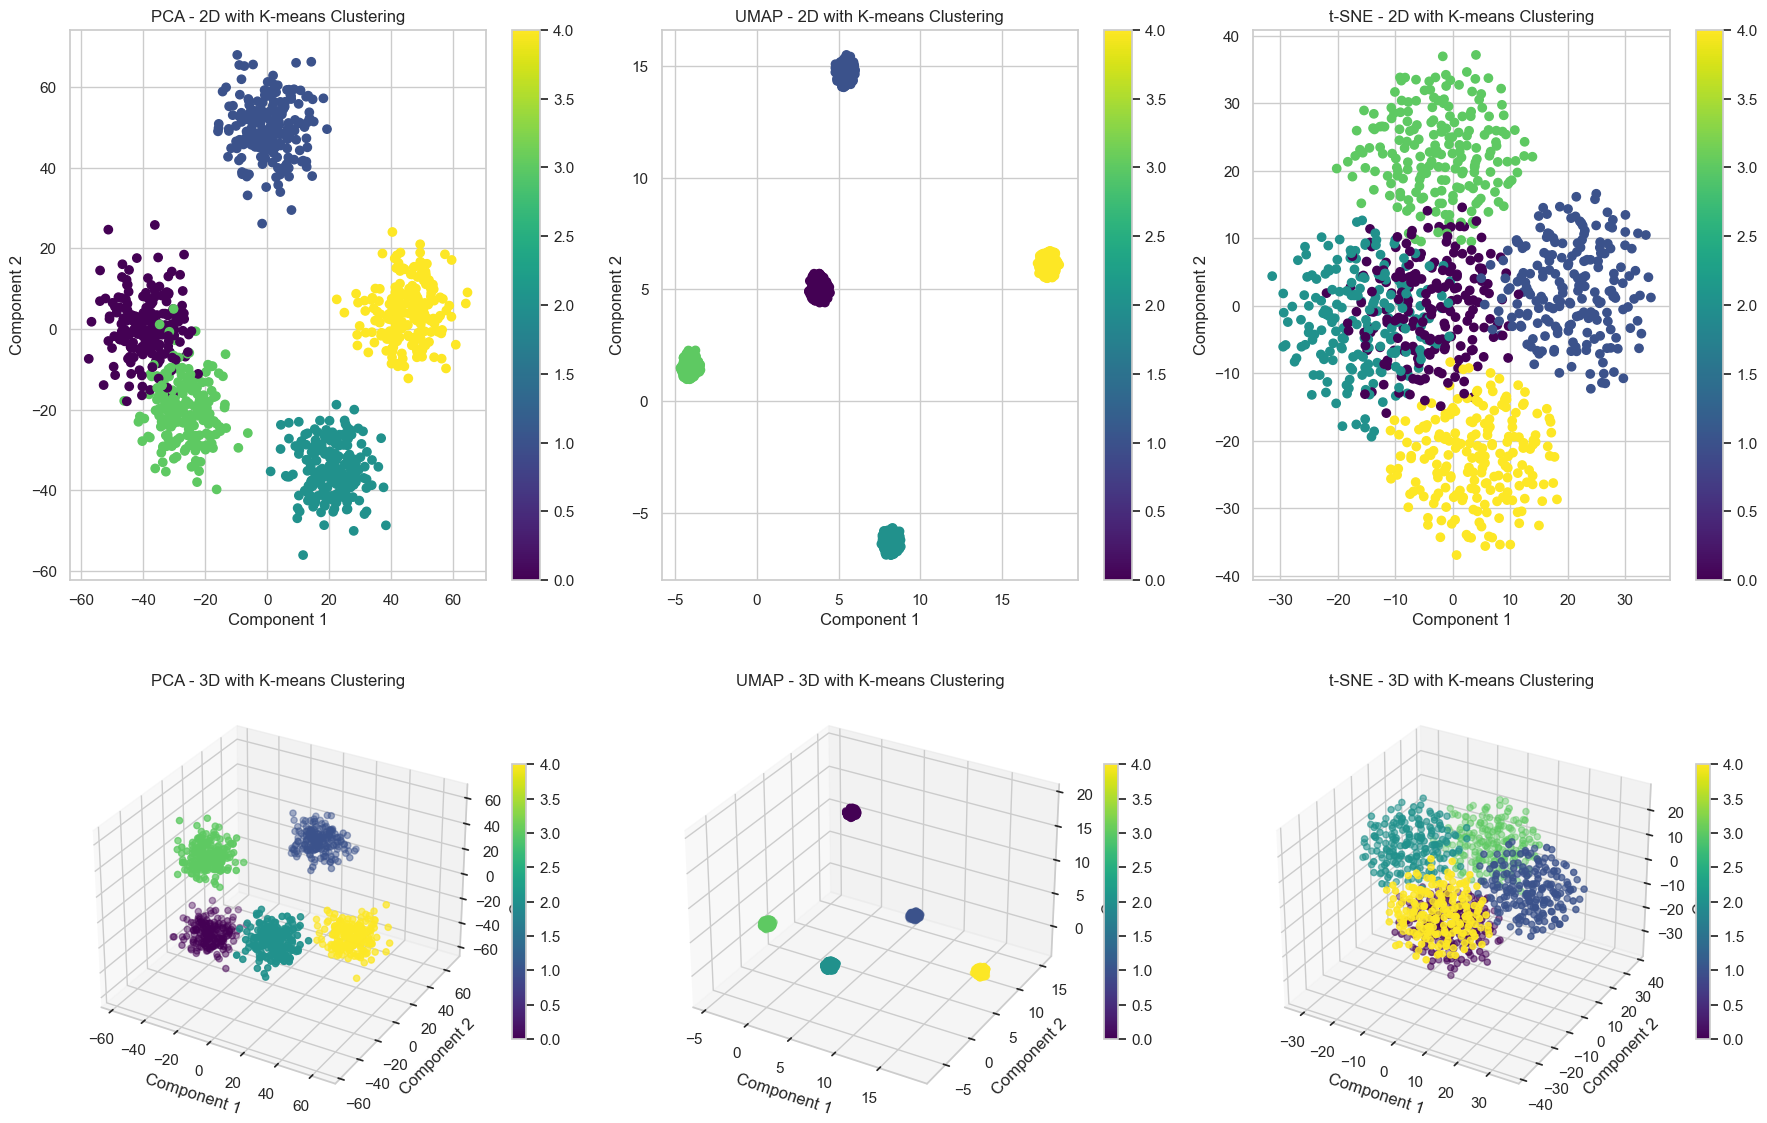

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, adjusted_rand_score, mutual_info_score

# Generate clustered data
n_samples = 1000
n_features = 100
n_clusters = 5

# Create data with clusters
X, true_labels = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, cluster_std=7, random_state=42)

# Dimensionality Reduction
# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# UMAP with adjusted parameters
reducer_umap = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, metric='euclidean')
X_umap = reducer_umap.fit_transform(X)

# t-SNE with adjusted parameters
tsne = TSNE(n_components=3, perplexity=30, early_exaggeration=12, random_state=42)
X_tsne = tsne.fit_transform(X)

# K-means Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_pca = kmeans.fit_predict(X_pca)
labels_umap = kmeans.fit_predict(X_umap)
labels_tsne = kmeans.fit_predict(X_tsne)

# Plotting
fig = plt.figure(figsize=(18, 18))

# 2D Plots with Cluster Labels
ax1 = fig.add_subplot(331)
scatter_pca_2d = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='viridis', marker='o')
ax1.set_title('PCA - 2D with K-means Clustering')
ax1.set_xlabel('Component 1')
ax1.set_ylabel('Component 2')
plt.colorbar(scatter_pca_2d, ax=ax1)

ax2 = fig.add_subplot(332)
scatter_umap_2d = ax2.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_umap, cmap='viridis', marker='o')
ax2.set_title('UMAP - 2D with K-means Clustering')
ax2.set_xlabel('Component 1')
ax2.set_ylabel('Component 2')
plt.colorbar(scatter_umap_2d, ax=ax2)

ax3 = fig.add_subplot(333)
scatter_tsne_2d = ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_tsne, cmap='viridis', marker='o')
ax3.set_title('t-SNE - 2D with K-means Clustering')
ax3.set_xlabel('Component 1')
ax3.set_ylabel('Component 2')
plt.colorbar(scatter_tsne_2d, ax=ax3)

# 3D Plots with Cluster Labels
ax4 = fig.add_subplot(334, projection='3d')
scatter_pca_3d = ax4.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_pca, cmap='viridis', marker='o')
ax4.set_title('PCA - 3D with K-means Clustering')
ax4.set_xlabel('Component 1')
ax4.set_ylabel('Component 2')
ax4.set_zlabel('Component 3')
plt.colorbar(scatter_pca_3d, ax=ax4, shrink=0.5)

ax5 = fig.add_subplot(335, projection='3d')
scatter_umap_3d = ax5.scatter(X_umap[:, 0], X_umap[:, 1], X_umap[:, 2], c=labels_umap, cmap='viridis', marker='o')
ax5.set_title('UMAP - 3D with K-means Clustering')
ax5.set_xlabel('Component 1')
ax5.set_ylabel('Component 2')
ax5.set_zlabel('Component 3')
plt.colorbar(scatter_umap_3d, ax=ax5, shrink=0.5)

ax6 = fig.add_subplot(336, projection='3d')
scatter_tsne_3d = ax6.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=labels_tsne, cmap='viridis', marker='o')
ax6.set_title('t-SNE - 3D with K-means Clustering')
ax6.set_xlabel('Component 1')
ax6.set_ylabel('Component 2')
ax6.set_zlabel('Component 3')
plt.colorbar(scatter_tsne_3d, ax=ax6, shrink=0.5)

plt.tight_layout()
plt.show()

## Calculate Clustering Metrics - Elbow Plot, WCSS, Silhouette, Rand_Index, Mutual Info (Figure 8C)

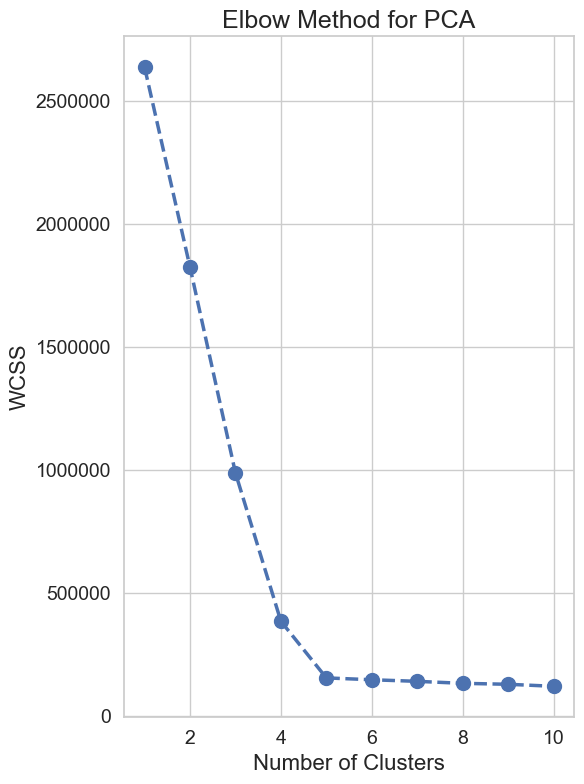

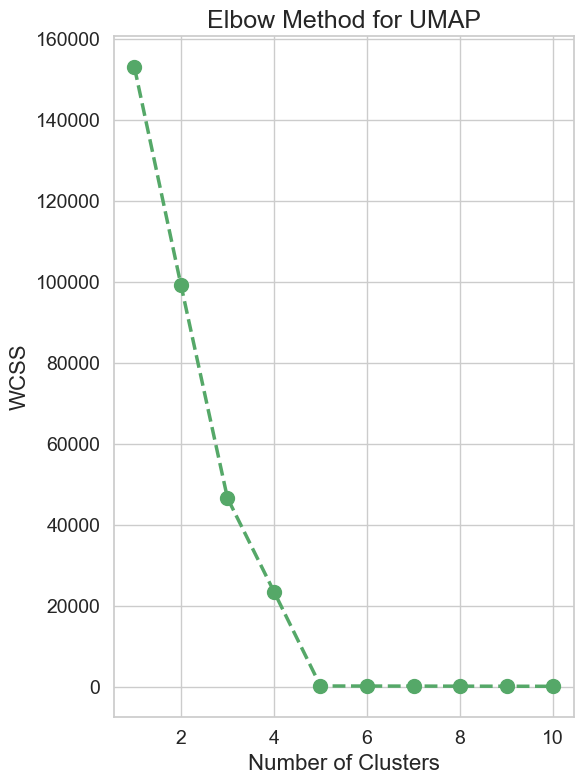

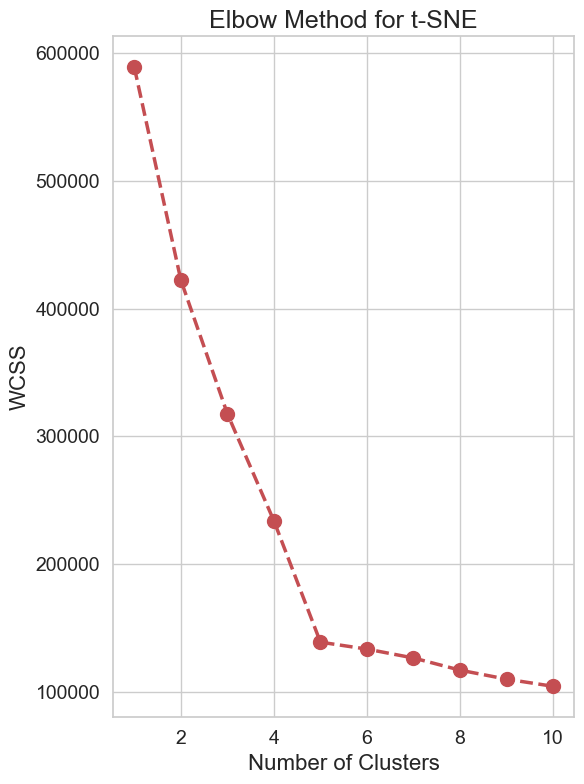

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, mutual_info_score
from matplotlib.ticker import ScalarFormatter

# Define cluster range
cluster_range = range(1, 11)

# Initialize lists for metrics
wcss_pca, silhouette_pca, rand_index_pca, mutual_info_pca = [], [], [], []
wcss_umap, silhouette_umap, rand_index_umap, mutual_info_umap = [], [], [], []
wcss_tsne, silhouette_tsne, rand_index_tsne, mutual_info_tsne = [], [], [], []

# List to collect metrics data
dfs_metrics = []

# Function for metric calculation per method
def evaluate_clustering(X_embedded, true_labels, method_name, color):
    """Compute clustering quality metrics.
    
    Returns common metrics such as silhouette score, adjusted Rand index, and mutual information.
    """

    wcss_list, silhouette_list, rand_index_list, mutual_info_list = [], [], [], []

    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
        kmeans.fit(X_embedded)
        labels = kmeans.labels_

        wcss_list.append(kmeans.inertia_)

        if n_clusters > 1:
            silhouette_list.append(silhouette_score(X_embedded, labels))
            rand_index_list.append(adjusted_rand_score(true_labels, labels))
            mutual_info_list.append(mutual_info_score(true_labels, labels))
        else:
            silhouette_list.append(np.nan)
            rand_index_list.append(np.nan)
            mutual_info_list.append(np.nan)

        df = pd.DataFrame({
            'Dimensionality Reduction': method_name,
            'Number of Clusters': [n_clusters],
            'WCSS': [kmeans.inertia_],
            'Silhouette Score': [silhouette_list[-1]],
            'Rand Index': [rand_index_list[-1]],
            'Mutual Information': [mutual_info_list[-1]]
        })
        dfs_metrics.append(df)

    # Plot Elbow
    plt.figure(figsize=(6, 8))  # Taller than wide
    plt.plot(
        cluster_range, wcss_list,
        marker='o', linestyle='--', color=color,
        linewidth=2.5, markersize=10
    )
    plt.title(f'Elbow Method for {method_name}', fontsize=18)
    plt.xlabel('Number of Clusters', fontsize=16)
    plt.ylabel('WCSS', fontsize=16)

    # Disable scientific notation
    ax = plt.gca()
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False, useOffset=False))
    ax.ticklabel_format(style='plain', axis='y')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return wcss_list, silhouette_list, rand_index_list, mutual_info_list

# === Run for PCA ===
wcss_pca, silhouette_pca, rand_index_pca, mutual_info_pca = evaluate_clustering(X_pca, true_labels, 'PCA', 'b')

# === Run for UMAP ===
wcss_umap, silhouette_umap, rand_index_umap, mutual_info_umap = evaluate_clustering(X_umap, true_labels, 'UMAP', 'g')

# === Run for t-SNE ===
wcss_tsne, silhouette_tsne, rand_index_tsne, mutual_info_tsne = evaluate_clustering(X_tsne, true_labels, 't-SNE', 'r')

# === Combine all into single DataFrame ===
df_metrics = pd.concat(dfs_metrics, ignore_index=True)

In [6]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# List to store individual DataFrames for each dimensionality reduction technique
dfs = []

# Iterate over each dimensionality reduction technique
for method in df_metrics['Dimensionality Reduction'].unique():

    # Filter the DataFrame for the current dimensionality reduction technique
    df_method = df_metrics[df_metrics['Dimensionality Reduction'] == method].copy()

    # Normalize the metrics
    df_method['WCSS Norm'] = scaler.fit_transform(df_method[['WCSS']])
    df_method['Silhouette Score Norm'] = scaler.fit_transform(df_method[['Silhouette Score']])
    df_method['Rand Index Norm'] = scaler.fit_transform(df_method[['Rand Index']])
    df_method['Mutual Information Norm'] = scaler.fit_transform(df_method[['Mutual Information']])

    # Invert WCSS normalization because lower is better
    df_method['WCSS Norm'] = 1 - df_method['WCSS Norm']

    # Calculate the combined score
    df_method['Combined Score'] = (df_method['Silhouette Score Norm'] +
                                   df_method['Rand Index Norm'] +
                                   df_method['Mutual Information Norm'] +
                                   df_method['WCSS Norm'])

    # Find the best row based on the combined score
    best_row = df_method.loc[df_method['Combined Score'].idxmax()]

    # Append the best row to the list of DataFrames
    dfs.append(pd.DataFrame({
        'Dimensionality Reduction': [method],
        'Number of Clusters': [best_row['Number of Clusters']],
        'WCSS': [best_row['WCSS']],
        'Silhouette Score': [best_row['Silhouette Score']],
        'Rand Index': [best_row['Rand Index']],
        'Mutual Information': [best_row['Mutual Information']]
    }))

# Concatenate all the individual DataFrames into the df_metrics
df_top_metrics_results = pd.concat(dfs, ignore_index=True)


In [7]:
df_top_metrics_results

,Dimensionality Reduction,Number of Clusters,WCSS,Silhouette Score,Rand Index,Mutual Information
0,PCA,5,153453.211469,0.729199,1.0,1.609438
1,UMAP,5,274.434509,0.955531,1.0,1.609438
2,t-SNE,5,138949.218750,0.446810,1.0,1.609438


# Grad-CAM (Figure 9B)

This section illustrates a Grad-CAM-style visualization.

Note: the example overlay in this notebook uses a **synthetic/fake heatmap** for visualization.


In [ ]:
## Change path to local repo ##
dir_path ='/path/here/2026-BoneRep-MLforBoneImaging'

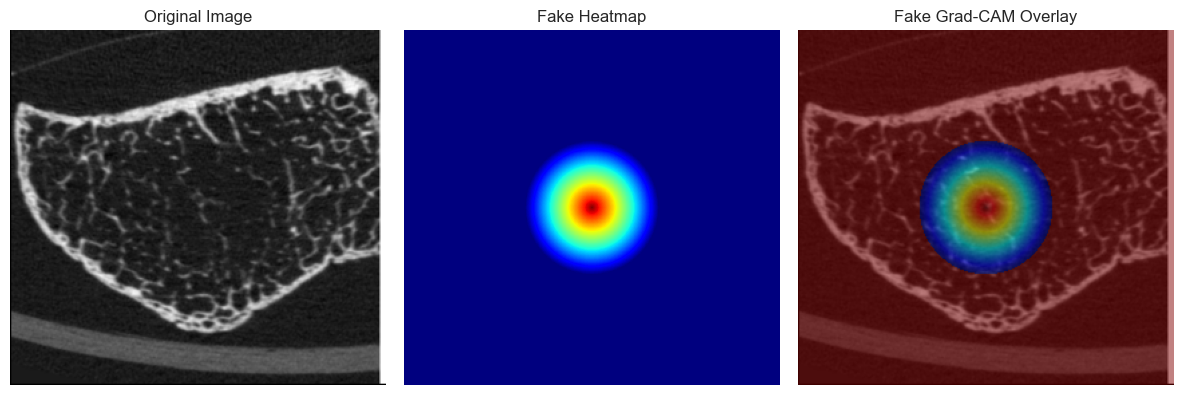

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def generate_fake_heatmap(image_shape, center=None, radius=50):
    """Create a fake circular heatmap mask."""
    h, w = image_shape[:2]
    if center is None:
        center = (w // 2, h // 2)

    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
    mask = np.clip(1 - dist_from_center / radius, 0, 1)
    return mask

def apply_colored_heatmap_on_image(image, heatmap, alpha=0.5):
    """Apply a colored heatmap to an image."""
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(image, 1 - alpha, heatmap_color, alpha, 0)
    return overlay

# === Load an example image ===
image_path = str(Path(dir_path) / 'images' / 'HRpQCT_Example.png')  # Example image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# === Create a fake heatmap ===
fake_heatmap = generate_fake_heatmap(image.shape, center=(image.shape[1]//2, image.shape[0]//2), radius=50)

# Normalize and convert to 0-255
fake_heatmap = cv2.resize(fake_heatmap, (image.shape[1], image.shape[0]))
fake_heatmap = (fake_heatmap * 255).astype(np.uint8)

# === Overlay heatmap ===
overlay_image = apply_colored_heatmap_on_image(image, fake_heatmap)

# === Display ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Fake Heatmap")
plt.imshow(fake_heatmap, cmap='jet')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Fake Grad-CAM Overlay")
plt.imshow(overlay_image)
plt.axis("off")

plt.tight_layout()
plt.show()

# Radar Plots (Figure 9D)
This section produces radar plots summarizing metrics.

- It produces plots inline.


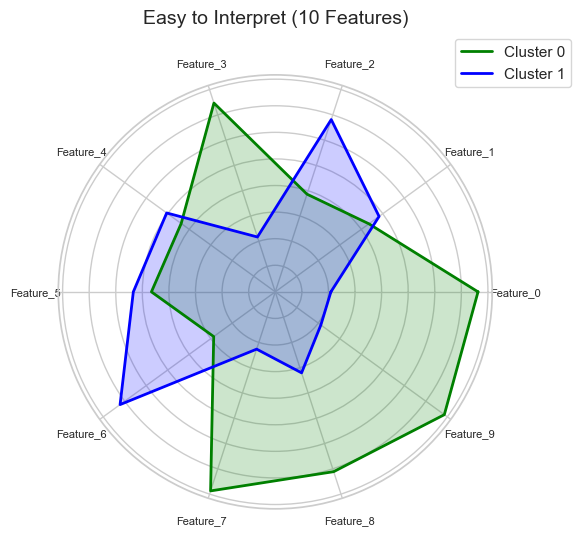

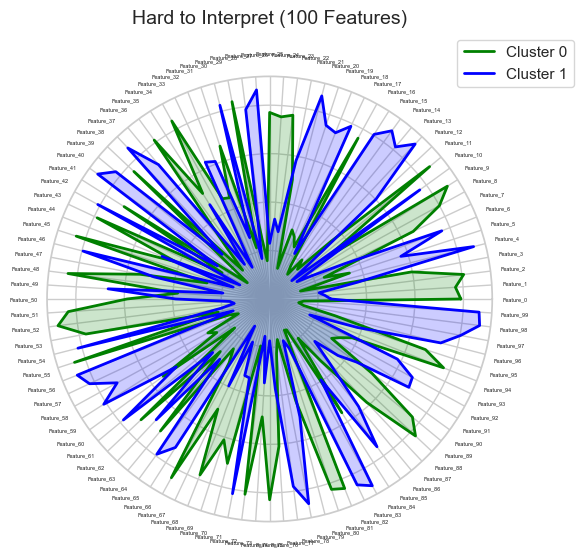

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from math import pi

# === Generate synthetic data with two settings ===
def generate_data(n_features):
    """Generate a synthetic classification dataset for demonstration plots.
    """

    X, labels = make_blobs(n_samples=500, n_features=n_features, centers=2, random_state=42)
    df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(n_features)])
    df['Cluster'] = labels
    return df

# === Radar plot function for a given cluster mean vector ===
def plot_radar(cluster_means, feature_labels, title, colors):
    """Plot a radar chart for a dict of metrics.
    """

    N = len(feature_labels)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # close circle

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'polar': True})

    for i, (label, color) in enumerate(zip(cluster_means.index, colors)):
        values = cluster_means.loc[label].values
        values = np.concatenate([values, [values[0]]])
        ax.plot(angles, values, label=f'Cluster {label}', color=color, linewidth=2)
        ax.fill(angles, values, color=color, alpha=0.2)

    ax.set_title(title, size=14, y=1.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels, fontsize=8 if N <= 20 else 4)  # reduce label font if too many
    ax.set_yticklabels([])
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.tight_layout()
    plt.show()

# === Shared cluster colors ===
cluster_colors = ['green', 'blue']

# === Easy to interpret: 10 features ===
df_easy = generate_data(n_features=10)
scaler_easy = MinMaxScaler()
df_easy.iloc[:, :-1] = scaler_easy.fit_transform(df_easy.iloc[:, :-1])
cluster_means_easy = df_easy.groupby('Cluster').mean()
plot_radar(cluster_means_easy, cluster_means_easy.columns, 'Easy to Interpret (10 Features)', colors=cluster_colors)

# === Hard to interpret: 100 features ===
df_hard = generate_data(n_features=100)
scaler_hard = MinMaxScaler()
df_hard.iloc[:, :-1] = scaler_hard.fit_transform(df_hard.iloc[:, :-1])
cluster_means_hard = df_hard.groupby('Cluster').mean()
plot_radar(cluster_means_hard, cluster_means_hard.columns, 'Hard to Interpret (100 Features)', colors=cluster_colors)

# Cluster-Classification-SHAP (Extra Concept - 9C)

This section demonstrates SHAP-style model explanations.

- It produces plots inline.
- If SHAP fails to import, see `docs/TROUBLESHOOTING.md`.


/Users/mdavid/anaconda3/envs/ML_models_utility/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



SHAP Summary for PCA
PCA - Cluster 0


/var/folders/qd/7nrqppz13dl6c5_qwj1lk_180000gn/T/ipykernel_88345/3554134720.py:75: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[..., i], X, plot_type='dot')


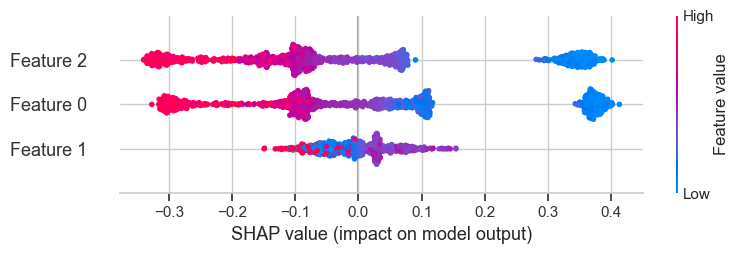

PCA - Cluster 1


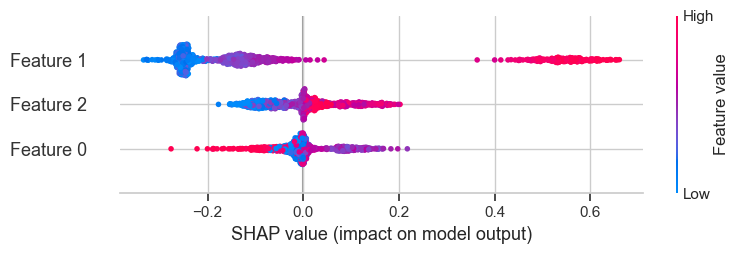

PCA - Cluster 2


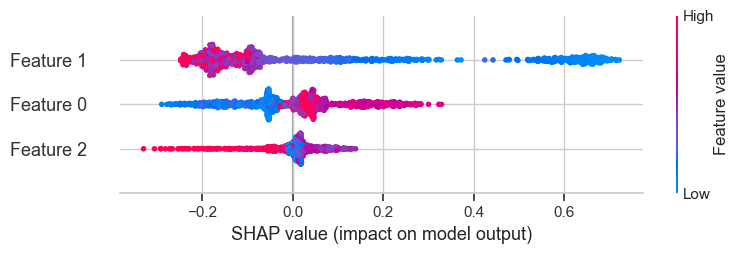

PCA - Cluster 3


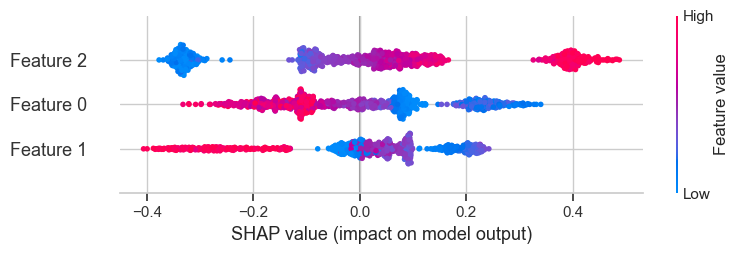

PCA - Cluster 4


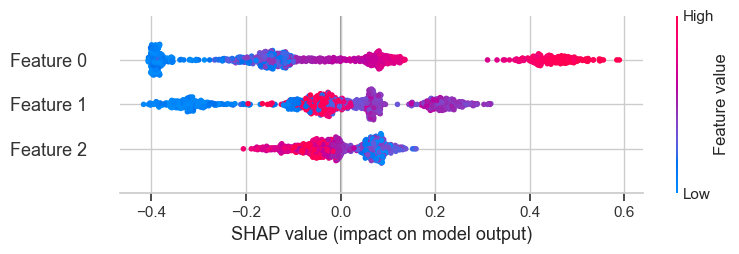


SHAP Summary for UMAP
UMAP - Cluster 0


/var/folders/qd/7nrqppz13dl6c5_qwj1lk_180000gn/T/ipykernel_88345/3554134720.py:75: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[..., i], X, plot_type='dot')


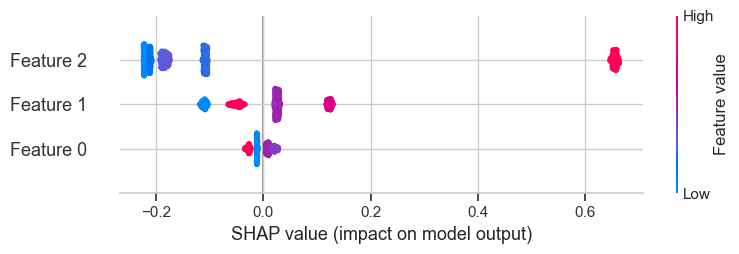

UMAP - Cluster 1


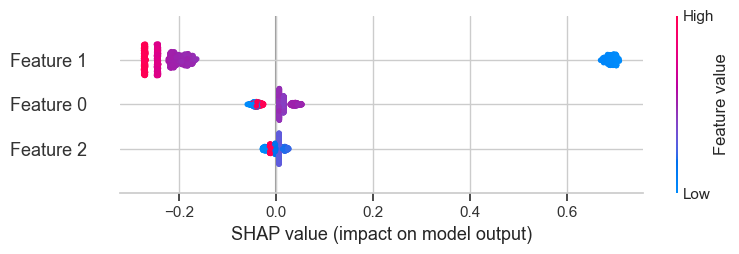

UMAP - Cluster 2


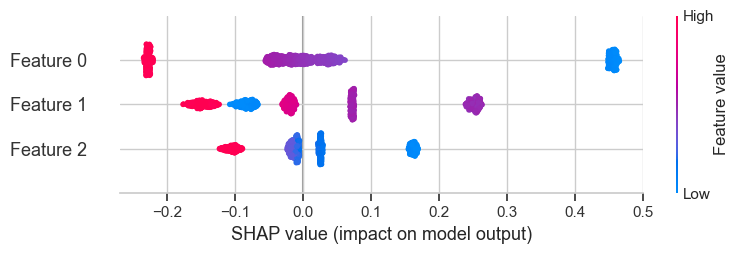

UMAP - Cluster 3


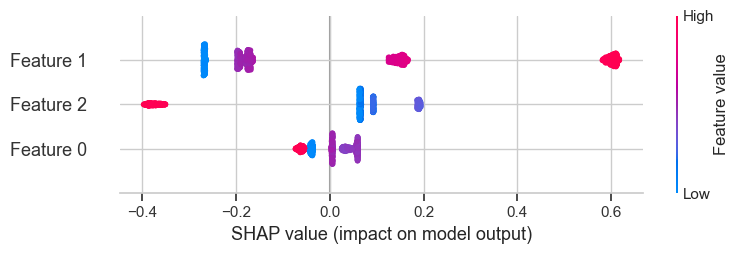

UMAP - Cluster 4


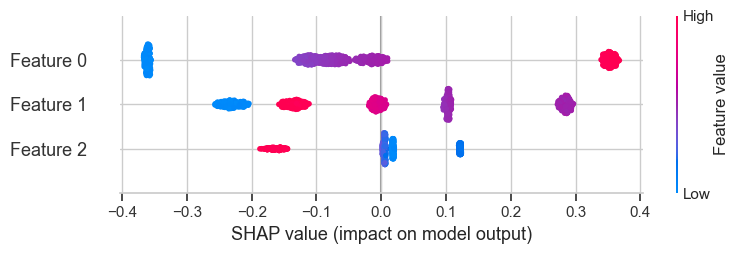


SHAP Summary for t-SNE
t-SNE - Cluster 0


/var/folders/qd/7nrqppz13dl6c5_qwj1lk_180000gn/T/ipykernel_88345/3554134720.py:75: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[..., i], X, plot_type='dot')


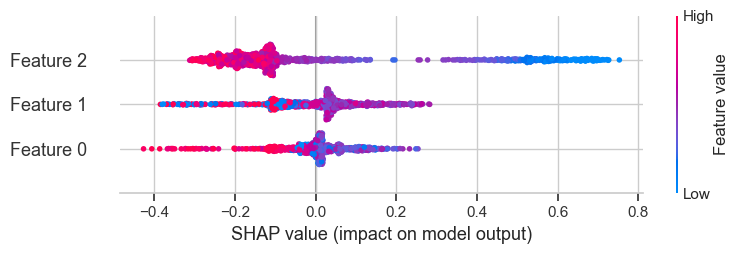

t-SNE - Cluster 1


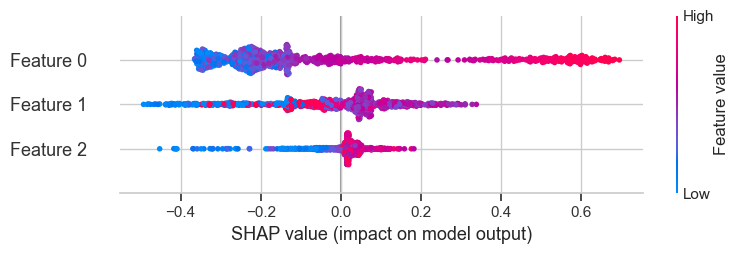

t-SNE - Cluster 2


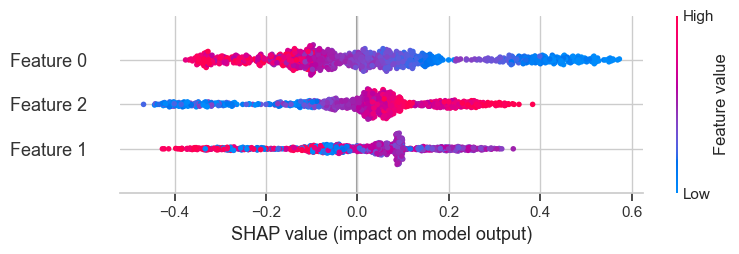

t-SNE - Cluster 3


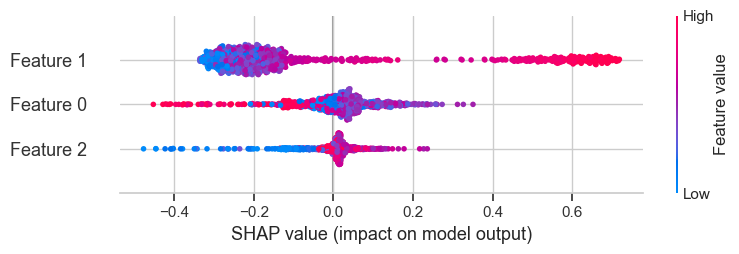

t-SNE - Cluster 4


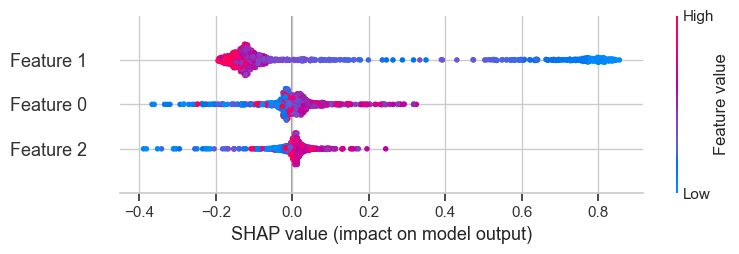


=== Evaluating on PCA ===
PCA + LogisticRegression: Accuracy = 1.0000
PCA + SVM: Accuracy = 1.0000
PCA + RandomForest: Accuracy = 1.0000


/Users/mdavid/anaconda3/envs/ML_models_utility/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [23:19:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


PCA + XGBoost: Accuracy = 1.0000
PCA + MLP: Accuracy = 1.0000

=== KMeans Clustering for PCA ===
Silhouette: 0.7292, ARI: 1.0000, MI: 1.6094

=== Evaluating on UMAP ===
UMAP + LogisticRegression: Accuracy = 1.0000
UMAP + SVM: Accuracy = 1.0000
UMAP + RandomForest: Accuracy = 1.0000


/Users/mdavid/anaconda3/envs/ML_models_utility/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [23:19:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


UMAP + XGBoost: Accuracy = 1.0000
UMAP + MLP: Accuracy = 1.0000

=== KMeans Clustering for UMAP ===
Silhouette: 0.9546, ARI: 1.0000, MI: 1.6094

=== Evaluating on t-SNE ===
t-SNE + LogisticRegression: Accuracy = 1.0000
t-SNE + SVM: Accuracy = 1.0000
t-SNE + RandomForest: Accuracy = 0.9967


/Users/mdavid/anaconda3/envs/ML_models_utility/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [23:19:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


t-SNE + XGBoost: Accuracy = 0.9900
t-SNE + MLP: Accuracy = 1.0000

=== KMeans Clustering for t-SNE ===
Silhouette: 0.4468, ARI: 1.0000, MI: 1.6094


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import shap
import umap

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    silhouette_score,
    adjusted_rand_score,
    mutual_info_score
)

# === Parameters ===
n_samples = 1000
n_features = 100
n_clusters = 5
test_size = 0.3
random_state = 42

# === Generate synthetic clustered data ===
X, true_labels = make_blobs(n_samples=n_samples, n_features=n_features,
                             centers=n_clusters, cluster_std=7, random_state=random_state)

# === Dimensionality Reduction ===
X_pca = PCA(n_components=3).fit_transform(X)
X_umap = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=random_state).fit_transform(X)
X_tsne = TSNE(n_components=3, perplexity=30, early_exaggeration=12, random_state=random_state).fit_transform(X)

# === KMeans Clustering ===
def run_kmeans(X_reduced):
    """Run KMeans clustering and return labels.
    """

    return KMeans(n_clusters=n_clusters, random_state=random_state).fit_predict(X_reduced)

labels_pca = run_kmeans(X_pca)
labels_umap = run_kmeans(X_umap)
labels_tsne = run_kmeans(X_tsne)

# === Fit classifier to cluster labels ===
def fit_classifier(X, y):
    """Fit a classifier model on (X_train, y_train) and return the trained model.
    """

    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    return model

model_pca = fit_classifier(X_pca, labels_pca)
model_umap = fit_classifier(X_umap, labels_umap)
model_tsne = fit_classifier(X_tsne, labels_tsne)

# === SHAP Explanation ===
def explain_with_shap(model, X, method_name):
    """Compute SHAP values for a fitted model (if supported) and display summary plots.
    """

    print(f"\nSHAP Summary for {method_name}")
    explainer = shap.Explainer(model.predict_proba, X)
    shap_values = explainer(X)
    for i in range(shap_values.shape[-1]):
        print(f"{method_name} - Cluster {i}")
        shap.summary_plot(shap_values[..., i], X, plot_type='dot')

explain_with_shap(model_pca, X_pca, "PCA")
explain_with_shap(model_umap, X_umap, "UMAP")
explain_with_shap(model_tsne, X_tsne, "t-SNE")

# === Classifier Dictionary ===
classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'MLP': MLPClassifier(max_iter=1000)
}

# === Training + Evaluation ===
results = {}

def train_and_evaluate(X, y, model_name, clf):

    """Train a model and return evaluation metrics (accuracy/ROC-AUC/etc.).

    """

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{model_name}: Accuracy = {acc:.4f}")
    return clf, y_pred

# === Clustering Evaluation ===
def evaluate_clustering(X, y_true, method_name):
    """Compute clustering quality metrics.
    
    Returns common metrics such as silhouette score, adjusted Rand index, and mutual information.
    """

    print(f"\n=== KMeans Clustering for {method_name} ===")
    y_kmeans = run_kmeans(X)
    silhouette = silhouette_score(X, y_kmeans)
    ari = adjusted_rand_score(y_true, y_kmeans)
    mi = mutual_info_score(y_true, y_kmeans)
    print(f"Silhouette: {silhouette:.4f}, ARI: {ari:.4f}, MI: {mi:.4f}")
    return y_kmeans

# === Run Classifier Training and Clustering Evaluation ===
embeddings = {'PCA': X_pca, 'UMAP': X_umap, 't-SNE': X_tsne}

for method_name, X_embed in embeddings.items():
    print(f"\n=== Evaluating on {method_name} ===")
    for clf_name, clf in classifiers.items():
        model, y_pred = train_and_evaluate(X_embed, true_labels, f"{method_name} + {clf_name}", clf)
        results[f"{method_name}_{clf_name}"] = {'model': model, 'y_pred': y_pred}

    evaluate_clustering(X_embed, true_labels, method_name)